In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Base model, initial model
file_path = 'base_sensitivity.json'
with open(file_path, 'r') as file:
    data = json.load(file)

# Select the 'unvac_children' section and aggregate each sublevel into one summation per number
unvac_children_data = data['unvac_children']

# Aggregating the unvac_children data by scenario number (second key)
aggregated_by_scenario = {}

# Iterating over all antigens and summing values by scenario
for antigen, scenarios in unvac_children_data.items():
    for scenario, value in scenarios.items():
        if scenario not in aggregated_by_scenario:
            aggregated_by_scenario[scenario] = 0
        aggregated_by_scenario[scenario] += value

# Converting the aggregated data into a DataFrame for better visualization
aggregated_by_scenario_df = pd.DataFrame(aggregated_by_scenario.items(), columns=['Scenario', 'Total_Unvaccinated'])
aggregated_by_scenario_df = aggregated_by_scenario_df.sort_values(by='Scenario').reset_index(drop=True)
# aggregated_by_scenario_df

In [4]:
# min missed dose model, initial model
with open('base_min_missed_sensitivity.json', 'r') as file:
    second_dataset = json.load(file)

# Extract 'unvac_children' from the second dataset and aggregate by scenario
second_unvac_children = second_dataset['unvac_children']
aggregated_second_dataset = {}

for antigen, scenarios in second_unvac_children.items():
    for scenario, value in scenarios.items():
        if scenario not in aggregated_second_dataset:
            aggregated_second_dataset[scenario] = 0
        aggregated_second_dataset[scenario] += value

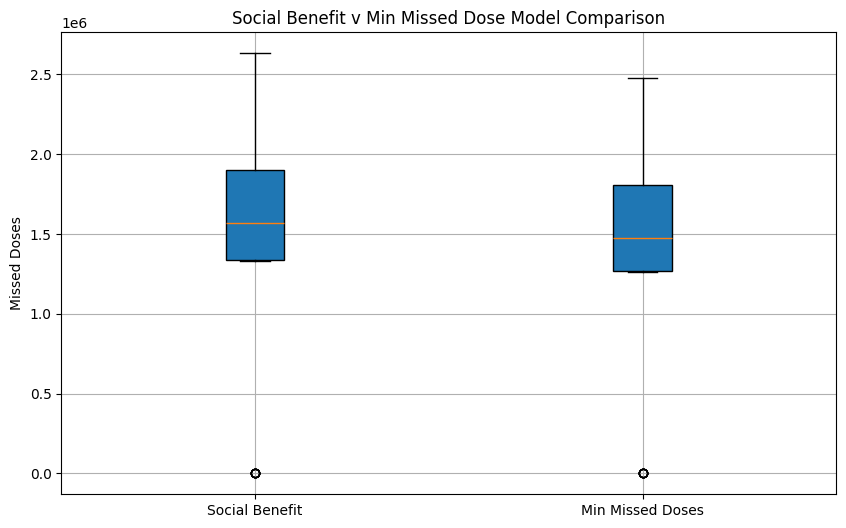

In [6]:


# Combine both datasets into a DataFrame for plotting
combined_data = pd.DataFrame({
    'Scenario': aggregated_by_scenario_df['Scenario'],
    'Dataset 1': aggregated_by_scenario_df['Total_Unvaccinated'],
    'Dataset 2': aggregated_second_dataset.values()
})

# Create a double box plot for the two datasets
plt.figure(figsize=(10, 6))
plt.boxplot([combined_data['Dataset 1'], combined_data['Dataset 2']], labels=['Social Benefit', 'Min Missed Doses'], patch_artist=True)
plt.title('Social Benefit v Min Missed Dose Model Comparison')
plt.ylabel('Missed Doses')
plt.grid(True)
plt.savefig('social_benefit_v_min_missed_missed_doses.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()
